## Celula 1: Conectarea si extragerea datelor

In [11]:
import pandas as pd
import numpy as np
import pyodbc
import warnings
warnings.filterwarnings('ignore')

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost,1433;"
    "DATABASE=ProductieSolaraDB_V2;"
    "UID=sa;"
    "PWD=Spidy400!"
)
conn = pyodbc.connect(conn_str)

df_train = pd.read_sql("SELECT Time_Stamp FROM Train", conn)

df_loggers = pd.read_sql("SELECT Time_Stamp, Loggers_0_Energy_Yield_Daily FROM LoggersTRENDS", conn)

df_meteo = pd.read_sql("SELECT Time_Stamp, Meteo_SolarIrradiation1, Meteo_SolarIrradiation2 FROM MeteoTRENDS", conn)

df_alarms = pd.read_sql("SELECT Al_Start_Time, Al_Message FROM ALARMHISTORY", conn)

df_train['Time_Stamp'] = pd.to_datetime(df_train['Time_Stamp'])
df_loggers['Time_Stamp'] = pd.to_datetime(df_loggers['Time_Stamp'])
df_meteo['Time_Stamp'] = pd.to_datetime(df_meteo['Time_Stamp'])
df_alarms['Al_Start_Time'] = pd.to_datetime(df_alarms['Al_Start_Time'])

## Celula 2: Agregarea zilnica si sincronizarea

In [12]:
data_start_oficiala = df_train['Time_Stamp'].min()
df_loggers = df_loggers[df_loggers['Time_Stamp'] >= data_start_oficiala]

df_loggers_daily = df_loggers.set_index('Time_Stamp').resample('D').agg({
    'Loggers_0_Energy_Yield_Daily': 'max'
}).reset_index()

df_meteo_daily = df_meteo.set_index('Time_Stamp').resample('D').agg({
    'Meteo_SolarIrradiation1': 'sum',
    'Meteo_SolarIrradiation2': 'sum'
}).reset_index()

zile_cu_alarme = df_alarms['Al_Start_Time'].dt.floor('D').unique()

df_daily = pd.merge(df_loggers_daily, df_meteo_daily, on='Time_Stamp', how='inner')
df_daily.rename(columns={'Time_Stamp': 'Date'}, inplace=True)

## Celula 3: Pruning + Extrapolarea productiei

In [ ]:
df_daily = pd.merge(df_loggers_daily, df_meteo_daily, on='Time_Stamp', how='inner')
df_daily.rename(columns={'Time_Stamp': 'Date'}, inplace=True)

df_daily = df_daily[df_daily['Date'].dt.dayofweek < 5]

df_daily = df_daily.dropna()
df_daily = df_daily[df_daily['Loggers_0_Energy_Yield_Daily'] > 10]

Q1 = df_daily['Loggers_0_Energy_Yield_Daily'].quantile(0.25)
Q3 = df_daily['Loggers_0_Energy_Yield_Daily'].quantile(0.75)
IQR = Q3 - Q1
limita_superioara = Q3 + 1.5 * IQR

df_daily = df_daily[df_daily['Loggers_0_Energy_Yield_Daily'] <= limita_superioara]

scaling_factor = 28 / 3
df_daily['Total_Park_Daily_Yield'] = df_daily['Loggers_0_Energy_Yield_Daily'] * scaling_factor

df_final = df_daily[['Date', 'Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2', 'Total_Park_Daily_Yield']].copy()

df_final.reset_index(drop=True, inplace=True)

display(df_final.head())
print(f"Dimensiunea setului de antrenare după pruning complet: {df_final.shape[0]} zile lucrătoare perfect curate.")

,Date,Meteo_SolarIrradiation1,Meteo_SolarIrradiation2,Total_Park_Daily_Yield
0,2026-05-18,855375.0,868304.0,63160.533333
1,2026-05-19,2974945.0,2996684.0,180418.000000
2,2026-05-20,3602664.0,3617848.0,198329.600000
3,2026-05-21,2921950.0,2969071.0,198329.600000
4,2026-05-22,3630213.0,3653717.0,152500.133333


Dimensiunea setului de antrenare după pruning complet: 26 zile lucrătoare perfect curate.


## Celula 4: Scalarea si crearea ferestrelor de timp

In [14]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

features = ['Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2']
target = ['Total_Park_Daily_Yield']

data_features = df_final[features].values
data_target = df_final[target].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(data_features)
scaled_y = scaler_y.fit_transform(data_target)

def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_seq, y_seq = create_sequences(scaled_X, scaled_y, TIME_STEPS)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"Forma X_train: {X_train.shape} -> (Samples, Time Steps, Features)")

Forma X_train: (16, 5, 2) -> (Samples, Time Steps, Features)


## Celula 5: Definirea si antrenarea algoritmilor

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_and_train_model(model_type, X_tr, y_tr, X_te, y_te):
    model = Sequential()
    
    if model_type == 'MLP':
        model.add(Flatten(input_shape=(X_tr.shape[1], X_tr.shape[2])))
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(32, activation='relu'))
        
    elif model_type == 'LSTM':
        model.add(LSTM(64, input_shape=(X_tr.shape[1], X_tr.shape[2])))
        model.add(Dropout(0.2))
        model.add(Dense(32, activation='relu'))
        
    elif model_type == 'GRU':
        model.add(GRU(64, input_shape=(X_tr.shape[1], X_tr.shape[2])))
        model.add(Dropout(0.2))
        model.add(Dense(32, activation='relu'))

    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    print(f"\n--- Antrenare model: {model_type} ---")
    history = model.fit(
        X_tr, y_tr,
        epochs=100,
        batch_size=16,
        validation_data=(X_te, y_te),
        callbacks=[early_stop],
        verbose=0
    )
    
    test_loss, test_mae = model.evaluate(X_te, y_te, verbose=0)
    
    y_pred_scaled = model.predict(X_te, verbose=0)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_te)
    
    return history, test_mae, y_test_real, y_pred_real

models_to_test = ['MLP', 'LSTM', 'GRU']
results = {}

for m in models_to_test:
    hist, mae, y_true, y_pred = build_and_train_model(m, X_train, y_train, X_test, y_test)
    results[m] = {
        'mae_scaled': mae,
        'y_true': y_true,
        'y_pred': y_pred
    }


--- Antrenare model: MLP ---

--- Antrenare model: LSTM ---

--- Antrenare model: GRU ---


## Celula 6: Compararea vizuala a modelelor

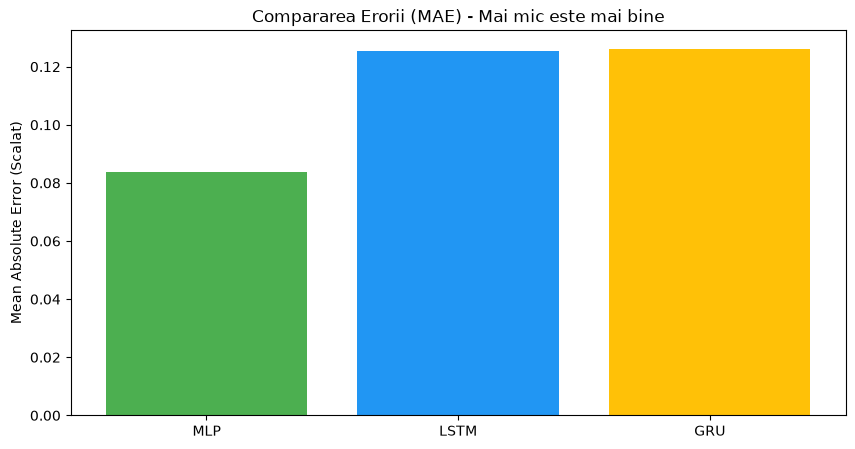

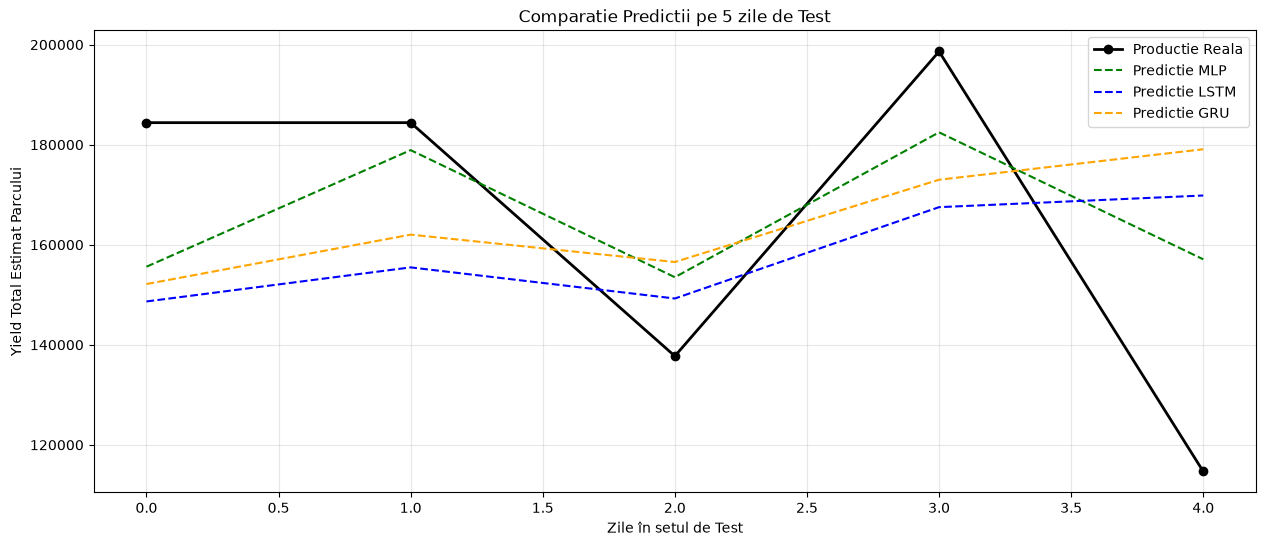

In [16]:
import matplotlib.pyplot as plt

num_samples = min(30, len(results['MLP']['y_true']))
timp_zile = range(num_samples)

plt.figure(figsize=(10, 5))
maes = [results[m]['mae_scaled'] for m in models_to_test]
plt.bar(models_to_test, maes, color=['#4CAF50', '#2196F3', '#FFC107'])
plt.title('Compararea Erorii (MAE) - Mai mic este mai bine')
plt.ylabel('Mean Absolute Error (Scalat)')
plt.show()

plt.figure(figsize=(15, 6))

plt.plot(timp_zile, results['MLP']['y_true'][:num_samples], label='Productie Reala', color='black', linewidth=2, marker='o')

colors = {'MLP': 'green', 'LSTM': 'blue', 'GRU': 'orange'}
for m in models_to_test:
    y_pred_flat = results[m]['y_pred'][:num_samples].flatten()
    plt.plot(timp_zile, y_pred_flat, label=f'Predictie {m}', color=colors[m], linestyle='dashed')

plt.title(f'Comparatie Predictii pe {num_samples} zile de Test')
plt.xlabel('Zile în setul de Test')
plt.ylabel('Yield Total Estimat Parcului')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Celula 7: Prognoza pe 2 saptamani (MLP)

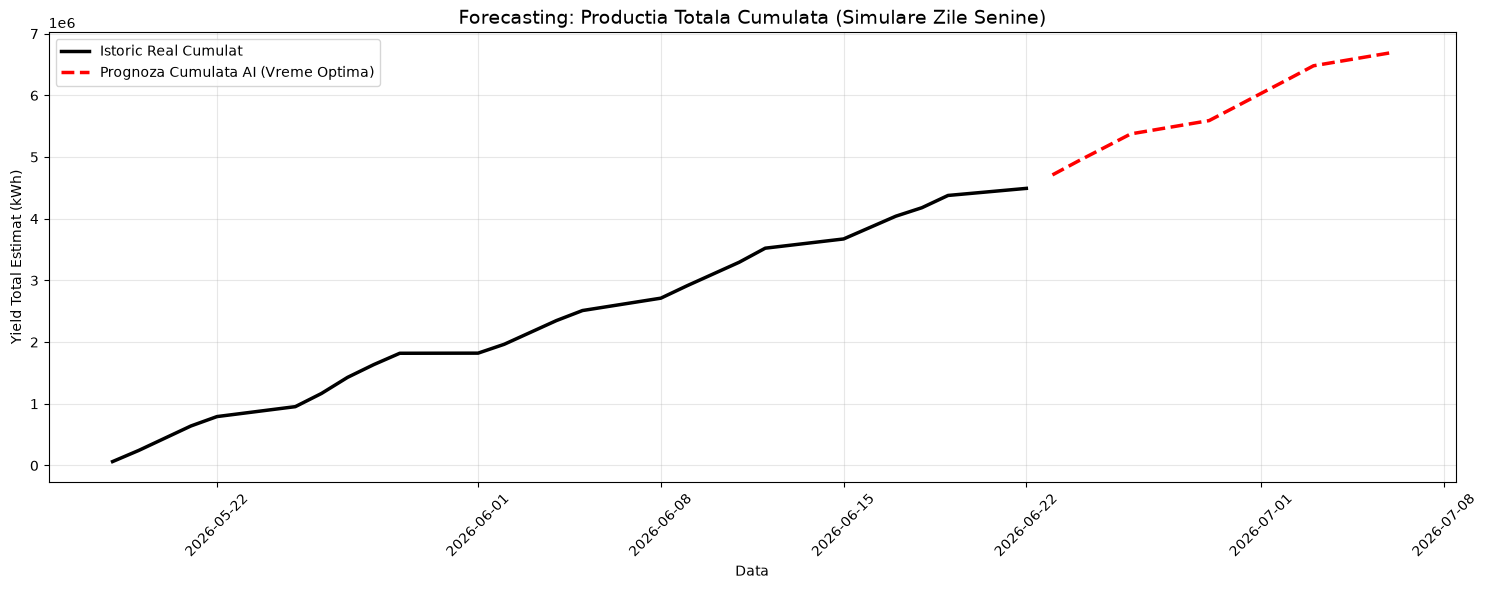


Productia zilnica estimata bazata pe conditii optime de vara:


,Data_Viitoare,Productie_Zilnica_Estimata_kWh,Total_Cumulat_kWh
0,2026-06-23,218557.125000,4710520.59
1,2026-06-24,227002.812500,4937523.40
2,2026-06-25,218203.453125,5155726.86
3,2026-06-26,219412.906250,5375139.76
4,2026-06-29,215492.000000,5590631.76
5,2026-06-30,220628.406250,5811260.17
6,2026-07-01,222332.906250,6033593.08
7,2026-07-02,221270.640625,6254863.72
8,2026-07-03,224643.312500,6479507.03
9,2026-07-06,214301.906250,6693808.92


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

X_vreme = df_final[['Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2']].values
y_energie = df_final[['Total_Park_Daily_Yield']].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_vreme)
y_scaled = scaler_y.fit_transform(y_energie)

model_forecast = Sequential([
    Dense(64, activation='relu', input_dim=2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_forecast.compile(optimizer='adam', loss='mse')
model_forecast.fit(X_scaled, y_scaled, epochs=150, verbose=0)

max_irrad = df_final[['Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2']].max().values

viitor_meteo = []
future_steps = 10

for _ in range(future_steps):
    irrad_1 = max_irrad[0] * random.uniform(0.98, 1.10)
    irrad_2 = max_irrad[1] * random.uniform(0.98, 1.10)
    viitor_meteo.append([irrad_1, irrad_2])

viitor_meteo_scaled = scaler_X.transform(viitor_meteo)
predictii_scaled = model_forecast.predict(viitor_meteo_scaled, verbose=0)
predictii_reale = scaler_y.inverse_transform(predictii_scaled)

istoric_cumulat = df_final['Total_Park_Daily_Yield'].cumsum()
ultima_valoare_reala = istoric_cumulat.iloc[-1]
predictii_cumulate = []
suma_curenta = ultima_valoare_reala

for valoare_zilnica in predictii_reale.flatten():
    suma_curenta += valoare_zilnica
    predictii_cumulate.append(suma_curenta)

last_known_date = df_final['Date'].iloc[-1]
future_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=future_steps)

plt.figure(figsize=(15, 6))

plt.plot(df_final['Date'], istoric_cumulat, 
         label='Istoric Real Cumulat', color='black', linewidth=2.5)
plt.plot(future_dates, predictii_cumulate, 
         label='Prognoza Cumulata AI (Vreme Optima)', color='red', linestyle='dashed', linewidth=2.5)

plt.title('Forecasting: Productia Totala Cumulata (Simulare Zile Senine)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Yield Total Estimat (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_forecast_cumulat = pd.DataFrame({
    'Data_Viitoare': future_dates,
    'Productie_Zilnica_Estimata_kWh': predictii_reale.flatten().round(2),
    'Total_Cumulat_kWh': np.array(predictii_cumulate).round(2)
})
print("\nProductia zilnica estimata bazata pe conditii optime de vara:")
display(df_forecast_cumulat)

## Celula 8: Prognoza pe 2 saptamani pentru MLP, LSTM si GRU

Antrenăm modelele... (poate dura câteva secunde)


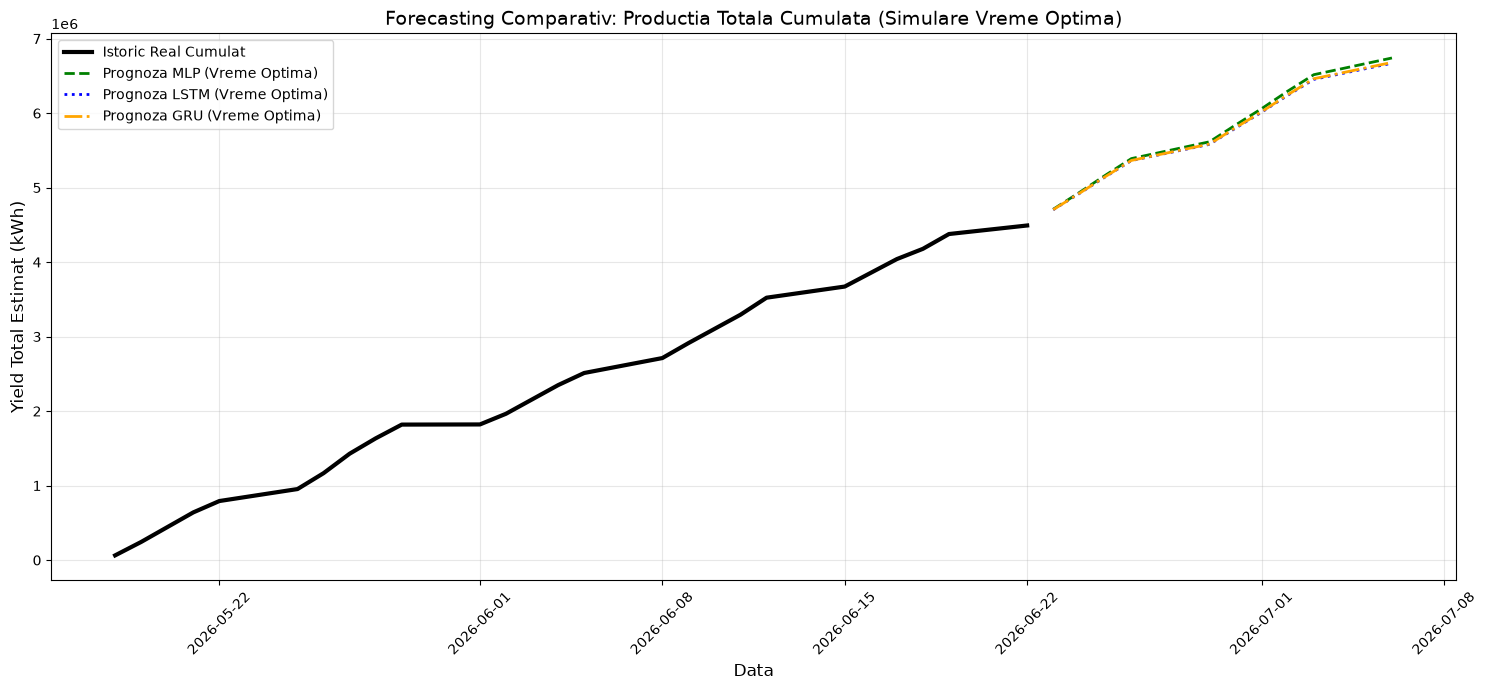


Comparație Producție Zilnică Estimată (Vreme Optimă):


,Data_Viitoare,Daily_MLP_kWh,Daily_LSTM_kWh,Daily_GRU_kWh
0,2026-06-23,217723.046875,211757.937500,212614.906250
1,2026-06-24,224159.046875,217562.187500,218108.593750
2,2026-06-25,232004.375000,224222.187500,225172.375000
3,2026-06-26,224118.781250,218278.859375,217323.812500
4,2026-06-29,225820.234375,217663.734375,220198.421875
5,2026-06-30,225618.843750,218234.546875,219832.453125
6,2026-07-01,219444.125000,213605.234375,213886.156250
7,2026-07-02,234858.593750,226775.000000,227663.703125
8,2026-07-03,220597.718750,213795.718750,215461.765625
9,2026-07-06,224458.046875,216888.000000,218967.703125


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from sklearn.preprocessing import MinMaxScaler

X_vreme = df_final[['Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2']].values
y_energie = df_final[['Total_Park_Daily_Yield']].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_vreme)
y_scaled = scaler_y.fit_transform(y_energie)

X_scaled_rnn = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

print("Antrenăm modelele... (poate dura câteva secunde)")

model_mlp = Sequential([
    Dense(64, activation='relu', input_dim=2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_mlp.compile(optimizer='adam', loss='mse')
model_mlp.fit(X_scaled, y_scaled, epochs=150, verbose=0)

model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(1, 2)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_scaled_rnn, y_scaled, epochs=150, verbose=0)

model_gru = Sequential([
    GRU(64, activation='relu', input_shape=(1, 2)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_scaled_rnn, y_scaled, epochs=150, verbose=0)

max_irrad = df_final[['Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2']].max().values
viitor_meteo = []
future_steps = 10

for _ in range(future_steps):
    irrad_1 = max_irrad[0] * random.uniform(0.98, 1.10)
    irrad_2 = max_irrad[1] * random.uniform(0.98, 1.10)
    viitor_meteo.append([irrad_1, irrad_2])

viitor_meteo_scaled = scaler_X.transform(viitor_meteo)
viitor_meteo_scaled_rnn = viitor_meteo_scaled.reshape((viitor_meteo_scaled.shape[0], 1, viitor_meteo_scaled.shape[1]))

pred_mlp = scaler_y.inverse_transform(model_mlp.predict(viitor_meteo_scaled, verbose=0)).flatten()
pred_lstm = scaler_y.inverse_transform(model_lstm.predict(viitor_meteo_scaled_rnn, verbose=0)).flatten()
pred_gru = scaler_y.inverse_transform(model_gru.predict(viitor_meteo_scaled_rnn, verbose=0)).flatten()

istoric_cumulat = df_final['Total_Park_Daily_Yield'].cumsum()
ultima_valoare_reala = istoric_cumulat.iloc[-1]

def calculeaza_cumulat(predictii_zilnice, start_val):
    cumulat = []
    curent = start_val
    for val in predictii_zilnice:
        curent += val
        cumulat.append(curent)
    return cumulat

cumulat_mlp = calculeaza_cumulat(pred_mlp, ultima_valoare_reala)
cumulat_lstm = calculeaza_cumulat(pred_lstm, ultima_valoare_reala)
cumulat_gru = calculeaza_cumulat(pred_gru, ultima_valoare_reala)

last_known_date = df_final['Date'].iloc[-1]
future_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=future_steps)

plt.figure(figsize=(15, 7))

plt.plot(df_final['Date'], istoric_cumulat, label='Istoric Real Cumulat', color='black', linewidth=3)

plt.plot(future_dates, cumulat_mlp, label='Prognoza MLP (Vreme Optima)', color='green', linestyle='dashed', linewidth=2)
plt.plot(future_dates, cumulat_lstm, label='Prognoza LSTM (Vreme Optima)', color='blue', linestyle='dotted', linewidth=2)
plt.plot(future_dates, cumulat_gru, label='Prognoza GRU (Vreme Optima)', color='orange', linestyle='dashdot', linewidth=2)

plt.title('Forecasting Comparativ: Productia Totala Cumulata (Simulare Vreme Optima)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Yield Total Estimat (kWh)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_forecast_comparativ = pd.DataFrame({
    'Data_Viitoare': future_dates,
    'Daily_MLP_kWh': pred_mlp.round(2),
    'Daily_LSTM_kWh': pred_lstm.round(2),
    'Daily_GRU_kWh': pred_gru.round(2)
})

print("\nComparatie Productie Zilnica Estimata (Vreme Optima):")
display(df_forecast_comparativ)